# Phase 0 — OpenFold on ubiquitin, end to end

Goal: run OpenFold on the 76-residue ubiquitin monomer, confirm the prediction matches
a reference structure, and leave a clean handle for extracting Evoformer intermediates.

**Before running this notebook**, complete the install (see `INSTALL.md` / the setup notes).
You need:
- `openfold_env` conda environment, activated as the Jupyter kernel
- AlphaFold params in `openfold/resources/params/`
- `LD_LIBRARY_PATH` and `LIBRARY_PATH` prepended with `$CONDA_PREFIX/lib`

### Checkpoints in this notebook
1. Imports succeed and the CUDA kernels loaded
2. MSA retrieved, depth is reasonable (expect hundreds to thousands for ubiquitin)
3. Inference runs, pLDDT is high (expect >90 nearly throughout)
4. C-alpha RMSD to PDB 1UBQ is small (expect well under 1 A over the ordered core)

If all four pass, the pipeline is trustworthy and you can start hooking the Evoformer.

## 0. Environment check

Run this first. If the OpenFold import fails here, nothing below will work and the problem
is the install, not the code.

In [1]:
import os, sys, json, subprocess, pathlib
import numpy as np
import torch

print("python     ", sys.version.split()[0])
print("torch      ", torch.__version__)
print("cuda avail ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device     ", torch.cuda.get_device_name(0))
    print("vram (GB)  ", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

import openfold
print("openfold   ", pathlib.Path(openfold.__file__).parent)

# The custom CUDA attention kernel. If this import fails, setup.py did not build it.
try:
    import attn_core_inplace_cuda
    print("cuda kernel  OK")
except ImportError as e:
    print("cuda kernel  MISSING ->", e)
    print("             rerun: python3 setup.py install  (with nvcc on PATH)")

python      3.10.20
torch       2.14.0+cu130
cuda avail  True
device      NVIDIA GeForce RTX 4060 Laptop GPU
vram (GB)   8.2
openfold    /home/caitlinlewis/repos/openfold/openfold
cuda kernel  OK


## 1. Configuration

Ubiquitin, human, 76 residues. This is the classic small single-domain test case.

**A caveat worth knowing up front.** There is no clean AlphaFold DB entry for the 76-residue
monomer. Human ubiquitin is encoded only as part of larger polyproteins:

| UniProt | Gene | Length | Notes |
|---|---|---|---|
| P0CG47 | UBB | 229 | polyubiquitin-B, 3 tandem copies |
| P0CG48 | UBC | 685 | polyubiquitin-C, 9 tandem copies |
| P62987 | UBA52 | 128 | ubiquitin (1-76) fused to ribosomal protein L40 |
| P62979 | RPS27A | 156 | ubiquitin (1-76) fused to ribosomal protein S27a |

So the primary ground truth here is **PDB 1UBQ** — a 1.8 A X-ray structure of exactly this
76-residue construct. AF-P62987-F1 residues 1-76 is a reasonable secondary check if you
want an AlphaFold-vs-AlphaFold comparison, but expect the fusion context to perturb the
C-terminal tail.

In [3]:
SEQUENCE = (
    "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"
)
NAME = "ubiquitin"
assert len(SEQUENCE) == 76

# model_3_ptm: no templates, has the PAE head. Keeps the pipeline minimal.
# Switch to model_1_ptm later if you want template inputs.
MODEL_NAME = "model_3_ptm"

OPENFOLD_DIR = pathlib.Path(os.environ.get("OPENFOLD_DIR", "~/repos/openfold")).expanduser()
PARAMS_PATH  = OPENFOLD_DIR / "openfold" / "resources" / "params" / f"params_{MODEL_NAME}.npz"

WORK = pathlib.Path("./work").resolve()
(WORK / "fasta").mkdir(parents=True, exist_ok=True)
(WORK / "alignments" / NAME).mkdir(parents=True, exist_ok=True)
(WORK / "out").mkdir(parents=True, exist_ok=True)
(WORK / "ref").mkdir(parents=True, exist_ok=True)

FASTA_PATH     = WORK / "fasta" / f"{NAME}.fasta"
ALIGNMENT_DIR  = WORK / "alignments"          # DataPipeline expects <dir>/<name>/*.a3m
A3M_PATH       = WORK / "alignments" / NAME / "mmseqs.a3m"

FASTA_PATH.write_text(f">{NAME}\n{SEQUENCE}\n")

print("params exists:", PARAMS_PATH.exists(), PARAMS_PATH)
print("work dir:     ", WORK)

params exists: True /home/caitlinlewis/repos/openfold/openfold/resources/params/params_model_3_ptm.npz
work dir:      /home/caitlinlewis/repos/mech-interp-sandbox/alpha-fold/work


## 2. Get the MSA

Using the ColabFold MMseqs2 server. This avoids installing HHblits/JackHMMER and
downloading several TB of sequence databases.

The alternative worth checking: the 2025 AlphaFold DB update exposes the underlying MSAs
for database entries. If you can pull the exact alignment AFDB used, your comparison
becomes much tighter. That path is not wired up here.

Be considerate with the public server — cache the result and do not re-query on every rerun.

In [4]:
if not A3M_PATH.exists():
    from colabfold.colabfold import run_mmseqs2
    # returns a3m lines for the query
    res = run_mmseqs2(
        SEQUENCE,
        prefix=str(WORK / "mmseqs_cache"),
        use_env=True,       # include environmental (MGnify-like) sequences
        use_filter=True,
        use_templates=False,
    )
    a3m_lines = res[0] if isinstance(res, (list, tuple)) else res
    A3M_PATH.write_text(a3m_lines)

a3m_text = A3M_PATH.read_text()
n_seqs = a3m_text.count(">")
print(f"MSA depth: {n_seqs} sequences")
print(f"a3m size:  {len(a3m_text)/1e6:.2f} MB")

# CHECKPOINT 2: ubiquitin is extremely well-conserved. Expect a deep alignment.
# A depth in the single or double digits means the query or the server call went wrong.
assert n_seqs > 100, "MSA is suspiciously shallow - check the server response"
print("\nfirst two entries:")
print("\n".join(a3m_text.splitlines()[:4]))

MSA depth: 21577 sequences
a3m size:  3.00 MB

first two entries:
>101
MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
>UniRef100_A0A6C0JTL4	115	0.894	3.629E-27	0	75	76	0	75	85
MQIFVKTLTGKTITLEVDPSNTIETVKQMIQDKEGIPPDQQRLIYAGKQLEDNRTLSDYNVQKESTLHLVLRLRGG


### Quick look at the alignment

Not strictly needed, but worth seeing once — this matrix is the input that carries the
structural signal. Gap-rich columns and the conservation pattern are both visible.

MSA matrix: (512, 76) (rows shown capped at 512)


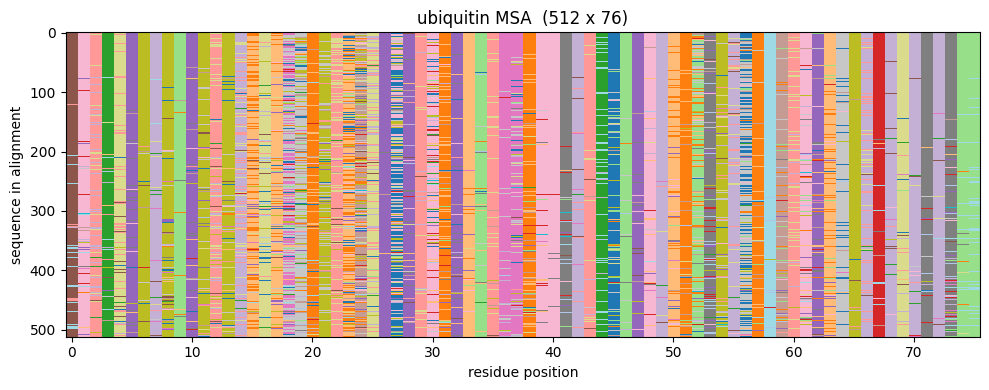

In [5]:
def parse_a3m_to_matrix(a3m_text, max_rows=512):
    """Crude a3m -> (n_seq, L) integer matrix. Lowercase = insertion relative to query, dropped."""
    seqs, cur = [], None
    for line in a3m_text.splitlines():
        if line.startswith(">"):
            if cur is not None:
                seqs.append(cur)
            cur = ""
        elif cur is not None:
            cur += line.strip()
    if cur:
        seqs.append(cur)
    seqs = [ "".join(ch for ch in s if not ch.islower()) for s in seqs ]
    L = len(seqs[0])
    seqs = [s for s in seqs if len(s) == L][:max_rows]
    alphabet = "ACDEFGHIKLMNPQRSTVWY-"
    lut = {ch: i for i, ch in enumerate(alphabet)}
    mat = np.array([[lut.get(ch, 20) for ch in s] for s in seqs], dtype=np.uint8)
    return mat

msa_mat = parse_a3m_to_matrix(a3m_text)
print("MSA matrix:", msa_mat.shape, "(rows shown capped at 512)")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(msa_mat, aspect="auto", interpolation="nearest", cmap="tab20")
ax.set_xlabel("residue position"); ax.set_ylabel("sequence in alignment")
ax.set_title(f"{NAME} MSA  ({msa_mat.shape[0]} x {msa_mat.shape[1]})")
plt.tight_layout(); plt.show()

## 3. Build the OpenFold feature dict

`DataPipeline.process_fasta` globs the per-target alignment directory for `.a3m` / `.sto`
files, so a single `mmseqs.a3m` is enough. `template_featurizer=None` is fine because
`model_3_ptm` does not consume templates.

In [8]:
from openfold.config import model_config
from openfold.data import data_pipeline, feature_pipeline

config = model_config(MODEL_NAME)

# Sanity: confirm the shapes this report assumes
print("evoformer blocks :", config.model.evoformer_stack.no_blocks)
print("c_m (msa chan)   :", config.model.evoformer_stack.c_m)
print("c_z (pair chan)  :", config.model.evoformer_stack.c_z)
print("structure layers :", config.model.structure_module.no_blocks)
print("recycles (max)   :", config.data.common.max_recycling_iters)
print("uses templates   :", config.data.common.use_templates)

dp = data_pipeline.DataPipeline(template_featurizer=None)
feature_dict = dp.process_fasta(
    fasta_path=str(FASTA_PATH),
    alignment_dir=str(ALIGNMENT_DIR / NAME),
)

fp = feature_pipeline.FeaturePipeline(config.data)
processed = fp.process_features(feature_dict, mode="predict")

for k in ["aatype", "msa_feat", "residue_index", "seq_mask"]:
    if k in processed:
        print(f"{k:16s}", tuple(processed[k].shape))

evoformer blocks : 48
c_m (msa chan)   : 256
c_z (pair chan)  : 128
structure layers : 8
recycles (max)   : 3
uses templates   : False


/home/caitlinlewis/repos/openfold/openfold/data/data_transforms.py:1261: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:356.)
  protein[k] = v[slices]


aatype           (76, 4)
msa_feat         (512, 76, 49, 4)
residue_index    (76, 4)
seq_mask         (76, 4)


## 4. Load weights and run inference

`import_jax_weights_` loads DeepMind's original AF2 parameters into the PyTorch module.
Note the `version` string must match the params file.

In [9]:
from openfold.model.model import AlphaFold
from openfold.utils.import_weights import import_jax_weights_
from openfold.utils.tensor_utils import tensor_tree_map

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AlphaFold(config)
model.eval()
import_jax_weights_(model, str(PARAMS_PATH), version=MODEL_NAME)
model = model.to(device)

batch = {k: torch.as_tensor(v, device=device) for k, v in processed.items()}

import time
t0 = time.time()
with torch.no_grad():
    out = model(batch)
print(f"inference: {time.time() - t0:.1f} s on {device}")

out = tensor_tree_map(lambda x: x.detach().cpu().numpy(), out)
print("\noutput keys:")
for k, v in sorted(out.items()):
    if hasattr(v, "shape"):
        print(f"  {k:34s} {tuple(v.shape)}")

W0912 14:13:38.222000 50682 torch/fx/_symbolic_trace.py:57] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
/home/caitlinlewis/repos/openfold/openfold/model/triangular_multiplicative_update.py:373: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:356.)
  z_cache.copy_(z[z_cache_slicer])
/home/caitlinlewis/repos/openfold/openfold/model/triangular_multiplicative_update.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be change

inference: 14.5 s on cuda

output keys:
  aligned_confidence_probs           (76, 76, 64)
  distogram_logits                   (76, 76, 64)
  experimentally_resolved_logits     (76, 37)
  final_affine_tensor                (76, 7)
  final_atom_mask                    (76, 37)
  final_atom_positions               (76, 37, 3)
  lddt_logits                        (76, 50)
  masked_msa_logits                  (512, 76, 23)
  max_predicted_aligned_error        ()
  msa                                (512, 76, 256)
  num_recycles                       ()
  pair                               (76, 76, 128)
  plddt                              (76,)
  predicted_aligned_error            (76, 76)
  ptm_score                          ()
  single                             (76, 384)
  tm_logits                          (76, 76, 64)


## 5. Confidence: pLDDT and PAE

Checkpoint 3. Ubiquitin should be predicted with very high confidence almost everywhere.
The last few residues (the flexible C-terminal `LRGG` tail, residues 73-76) are the
expected exception — that tail is genuinely mobile and is the part that gets covalently
attached to substrate proteins.

mean pLDDT : 95.5
min  pLDDT : 45.7  at residue 76
pTM        : n/a


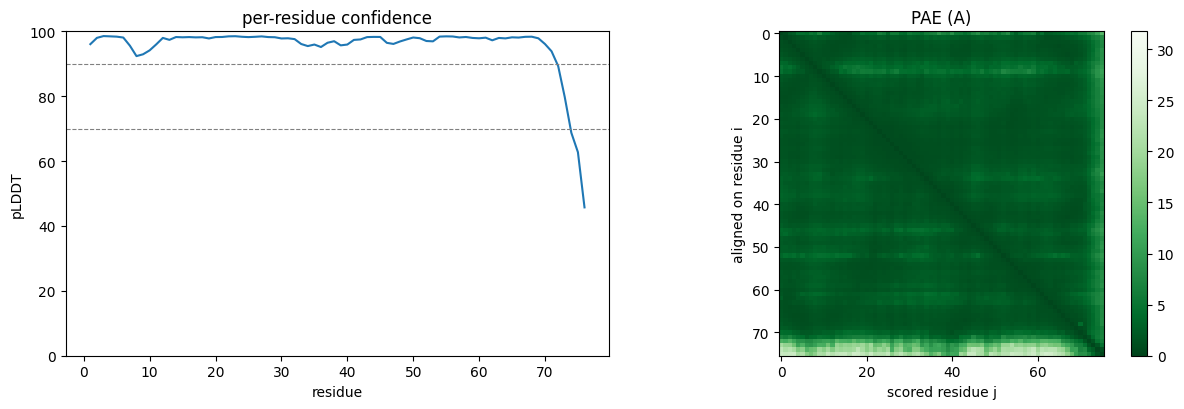


checkpoint 3 passed


In [10]:
plddt = out["plddt"]                                  # (L,)
pae   = out.get("predicted_aligned_error")            # (L, L) - present for *_ptm models
ptm   = float(out["predicted_tm_score"]) if "predicted_tm_score" in out else None

print(f"mean pLDDT : {plddt.mean():.1f}")
print(f"min  pLDDT : {plddt.min():.1f}  at residue {int(plddt.argmin()) + 1}")
print(f"pTM        : {ptm:.3f}" if ptm is not None else "pTM        : n/a")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(np.arange(1, len(plddt) + 1), plddt, lw=1.5)
axes[0].axhline(90, ls="--", lw=0.8, c="gray")
axes[0].axhline(70, ls="--", lw=0.8, c="gray")
axes[0].set_ylim(0, 100); axes[0].set_xlabel("residue"); axes[0].set_ylabel("pLDDT")
axes[0].set_title("per-residue confidence")

if pae is not None:
    im = axes[1].imshow(pae, cmap="Greens_r", vmin=0, vmax=31.75, origin="upper")
    axes[1].set_xlabel("scored residue j"); axes[1].set_ylabel("aligned on residue i")
    axes[1].set_title("PAE (A)")
    fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

# CHECKPOINT 3
assert plddt[:70].mean() > 85, "confidence too low for ubiquitin - something is wrong upstream"
print("\ncheckpoint 3 passed")

## 6. Write the predicted structure

In [22]:
from openfold.np import protein, residue_constants

# drop the recycling dimension — batch features are (..., num_recycles) in predict mode
batch_last = {k: v[..., -1].cpu().numpy() for k, v in batch.items()}

plddt_b = np.repeat(plddt[:, None], residue_constants.atom_type_num, axis=-1)

unrelaxed = protein.from_prediction(
    features=batch_last,
    result=out,
    b_factors=plddt_b,
    remove_leading_feature_dimension=False
)
pred_pdb_path = WORK / "out" / f"{NAME}_{MODEL_NAME}.pdb"
pred_pdb_path.write_text(protein.to_pdb(unrelaxed))

# verify before moving on
n_ca = sum(1 for l in pred_pdb_path.read_text().splitlines()
           if l.startswith("ATOM") and l[12:16].strip() == "CA")
print(f"wrote {pred_pdb_path}  ({n_ca} CA atoms)")
assert n_ca == len(SEQUENCE), f"expected {len(SEQUENCE)} CA atoms, got {n_ca}"

wrote /home/caitlinlewis/repos/mech-interp-sandbox/alpha-fold/work/out/ubiquitin_model_3_ptm.pdb  (76 CA atoms)


## 7. Compare against PDB 1UBQ

Checkpoint 4. Kabsch superposition on C-alpha atoms, then RMSD.

Two numbers are worth reporting:
- **All 76 residues** — will be inflated by the flexible C-terminal tail
- **Residues 1-72** — the ordered core; this is the number that should be small

For a well-predicted small single-domain protein, expect the core RMSD to land well under
1 A. If it is above ~2 A, stop and debug rather than proceeding to the Evoformer hooks.

In [49]:
import urllib.request

ref_path = WORK / "ref" / "1ubq.pdb"
if not ref_path.exists():
    urllib.request.urlretrieve("https://files.rcsb.org/download/1UBQ.pdb", ref_path)
    print("downloaded 1UBQ")

def ca_coords_from_pdb(path, chain=None):
    """Minimal CA extractor. Returns (resnum, coords) with altloc A/blank only."""
    nums, xyz = [], []
    for line in pathlib.Path(path).read_text().splitlines():
        if not line.startswith("ATOM"):
            continue
        if line[12:16].strip() != "CA":
            continue
        if line[16] not in (" ", "A"):
            continue
        if chain is not None and line[21] != chain:
            continue
        nums.append(int(line[22:26]))
        xyz.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return np.array(nums), np.array(xyz)

def kabsch_rmsd(P, Q):
    """RMSD after optimal superposition of P onto Q."""
    Pc, Qc = P - P.mean(0), Q - Q.mean(0)
    V, S, Wt = np.linalg.svd(Pc.T @ Qc)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1.0, 1.0, d])
    R = V @ D @ Wt
    Pr = Pc @ R
    return float(np.sqrt(((Pr - Qc) ** 2).sum() / len(P))), Pr, Qc

ref_nums, ref_cb = cb_coords_from_pdb(ref_path, chain="A")
ref_cm, ref_d = contact_map_from_ca(ref_cb)

common = np.intersect1d(ref_nums, pred_nums)
ri = np.searchsorted(ref_nums, common)
pi = np.searchsorted(pred_nums, common)
print(f"matched residues: {len(common)} (ref {len(ref_nums)}, pred {len(pred_nums)})")

rmsd_all, Pr, Qc = kabsch_rmsd(pred_ca[pi], ref_ca[ri])

core = common <= 72
rmsd_core, _, _ = kabsch_rmsd(pred_ca[pi][core], ref_ca[ri][core])

print(f"\nCA RMSD, all residues : {rmsd_all:.2f} A")
print(f"CA RMSD, residues 1-72: {rmsd_core:.2f} A")

# CHECKPOINT 4
assert rmsd_core < 2.0, "core RMSD too high - investigate before proceeding"
print("\ncheckpoint 4 passed")

matched residues: 76 (ref 76, pred 76)

CA RMSD, all residues : 0.78 A
CA RMSD, residues 1-72: 0.39 A

checkpoint 4 passed


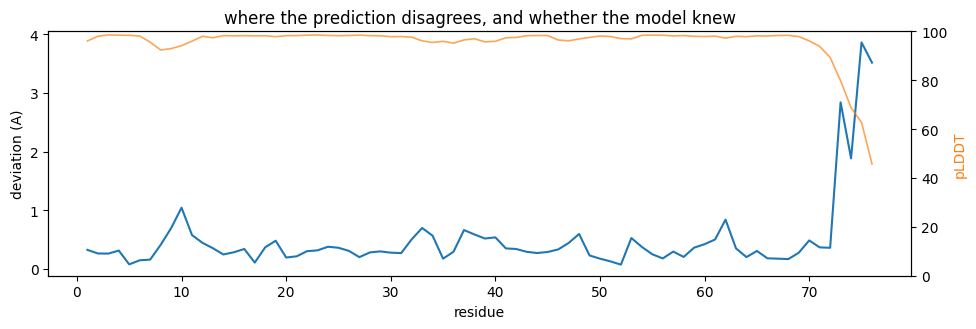

Expect deviation to spike at the C-terminal tail (73-76) and pLDDT to drop there.
Deviation high where pLDDT is high would be a red flag.


In [50]:
# per-residue deviation after core superposition, alongside pLDDT
Pc = pred_ca[pi] - pred_ca[pi][core].mean(0)
Qc2 = ref_ca[ri] - ref_ca[ri][core].mean(0)
V, S, Wt = np.linalg.svd((pred_ca[pi][core] - pred_ca[pi][core].mean(0)).T
                         @ (ref_ca[ri][core] - ref_ca[ri][core].mean(0)))
d = np.sign(np.linalg.det(V @ Wt))
R = V @ np.diag([1.0, 1.0, d]) @ Wt
dev = np.linalg.norm(Pc @ R - Qc2, axis=1)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(common, dev, lw=1.5, label="CA deviation vs 1UBQ (A)")
ax2 = ax.twinx()
ax2.plot(np.arange(1, len(plddt) + 1), plddt, lw=1.2, c="tab:orange", alpha=0.7, label="pLDDT")
ax2.set_ylim(0, 100); ax2.set_ylabel("pLDDT", color="tab:orange")
ax.set_xlabel("residue"); ax.set_ylabel("deviation (A)")
ax.set_title("where the prediction disagrees, and whether the model knew")
plt.tight_layout(); plt.show()

print("Expect deviation to spike at the C-terminal tail (73-76) and pLDDT to drop there.")
print("Deviation high where pLDDT is high would be a red flag.")

## 8. Contact map vs truth — the split-triangle figure

The convention in contact-prediction work: upper triangle is the prediction, lower triangle
is experimental truth, mirrored across the diagonal. This is the figure format the hero
image for the post will eventually use, so it is worth building the helper now.

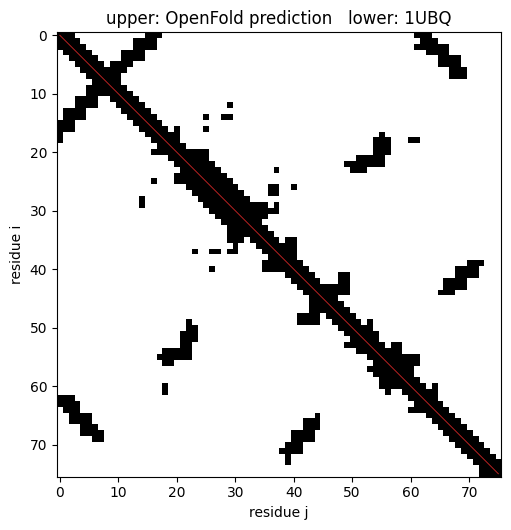

contact agreement at 8 A cutoff: 99.4%


In [51]:
def contact_map_from_ca(ca, cutoff=8.0):
    d = np.linalg.norm(ca[:, None, :] - ca[None, :, :], axis=-1)
    return (d < cutoff).astype(float), d

pred_cm, pred_d = contact_map_from_ca(pred_ca[pi])
ref_cm,  ref_d  = contact_map_from_ca(ref_ca[ri])

split = np.triu(pred_cm) + np.tril(ref_cm, -1)

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.imshow(split, cmap="Greys", vmin=0, vmax=1, origin="upper", interpolation="nearest")
ax.plot([0, len(split) - 1], [0, len(split) - 1], lw=0.6, c="tab:red")
ax.set_xlabel("residue j"); ax.set_ylabel("residue i")
ax.set_title("upper: OpenFold prediction   lower: 1UBQ")
plt.tight_layout(); plt.show()

agree = (pred_cm == ref_cm).mean()
print(f"contact agreement at 8 A cutoff: {agree*100:.1f}%")

In [52]:
tp = ((pred_cm == 1) & (ref_cm == 1)).sum()
fp = ((pred_cm == 1) & (ref_cm == 0)).sum()
fn = ((pred_cm == 0) & (ref_cm == 1)).sum()
print(f"precision {tp/(tp+fp):.3f}  recall {tp/(tp+fn):.3f}")

# long-range only (|i-j| > 12) — the part that isn't trivially predictable
L = len(pred_cm)
sep = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :])
lr = sep > 12
tp_lr = ((pred_cm == 1) & (ref_cm == 1) & lr).sum()
fp_lr = ((pred_cm == 1) & (ref_cm == 0) & lr).sum()
fn_lr = ((pred_cm == 0) & (ref_cm == 1) & lr).sum()
print(f"long-range: precision {tp_lr/(tp_lr+fp_lr):.3f}  recall {tp_lr/(tp_lr+fn_lr):.3f}")

precision 0.970  recall 0.986
long-range: precision 0.946  recall 0.967


## 9. Handle for the Evoformer intermediates

Not the goal of this notebook, but this is where the next one picks up. The point of
interest is `model.evoformer`, a `nn.ModuleList` of 48 `EvoformerBlock`s. A forward hook
on each block gives you `(m, z)` — the MSA and pair representations — at every depth.

Three things to sort out in the next notebook:

1. **Recycling.** `model.forward` calls the trunk once per recycle iteration. A naive hook
   fires 4x per block and you need to tag which pass you are in.
2. **Memory.** At `L=76` the full `(4, 48, 76, 76, 128)` pair tensor is ~568 MB at fp32 —
   fine to hold. At `L=300` this is 8.8 GB and the strategy has to change.
3. **The distogram head.** `model.aux_heads.distogram` is a single linear layer on the pair
   representation. Applying it at intermediate blocks is off-distribution (it was only
   trained on the final block) — that caveat belongs in the post, not hidden.

The cell below only confirms the module structure. Do not enable capture yet.

In [53]:
print("evoformer blocks:", len(model.evoformer.blocks))
blk = model.evoformer.blocks[0]
print("\nblock 0 submodules:")
for name, _ in blk.named_children():
    print("  ", name)

print("\naux heads:")
for name, _ in model.aux_heads.named_children():
    print("  ", name)

# the distogram head, for later reuse at arbitrary blocks
dg = model.aux_heads.distogram
print("\ndistogram head:", dg)
print("pair rep memory, one block, fp32:",
      f"{len(SEQUENCE)**2 * config.model.evoformer_stack.c_z * 4 / 1e6:.1f} MB")
print("all 48 blocks x 4 passes:",
      f"{len(SEQUENCE)**2 * config.model.evoformer_stack.c_z * 4 * 48 * 4 / 1e9:.2f} GB")

evoformer blocks: 48

block 0 submodules:
   msa_att_row
   msa_dropout_layer
   msa_transition
   outer_product_mean
   pair_stack
   msa_att_col

aux heads:
   plddt
   distogram
   masked_msa
   experimentally_resolved
   tm

distogram head: DistogramHead(
  (linear): Linear(in_features=128, out_features=64, bias=True)
)
pair rep memory, one block, fp32: 3.0 MB
all 48 blocks x 4 passes: 0.57 GB


In [54]:
for name, _ in blk.pair_stack.named_children():
    print("  ", name)

   tri_mul_out
   tri_mul_in
   tri_att_start
   tri_att_end
   pair_transition
   ps_dropout_row_layer


In [55]:
h = blk.register_forward_hook(lambda m, a, o: print("out type:", type(o),
    [tuple(t.shape) for t in o] if isinstance(o, tuple) else tuple(o.shape)))
with torch.no_grad():
    _ = model(batch)
h.remove()

out type: <class 'tuple'> [(512, 76, 256), (76, 76, 128)]
out type: <class 'tuple'> [(512, 76, 256), (76, 76, 128)]
out type: <class 'tuple'> [(512, 76, 256), (76, 76, 128)]
out type: <class 'tuple'> [(512, 76, 256), (76, 76, 128)]


In [56]:
captures = []          # flat list of (block_idx, z) in firing order
def make_hook(i):
    def hook(module, args, output):
        captures.append((i, output[1].detach()))   # z only, stays on GPU
    return hook

handles = [blk.register_forward_hook(make_hook(i))
           for i, blk in enumerate(model.evoformer.blocks)]

captures.clear()
with torch.no_grad():
    _ = model(batch)
for h in handles:
    h.remove()

print(f"captured {len(captures)} tensors (expect 192)")
print("block order, first 6:", [b for b, _ in captures[:6]])
print("block order, at recycle boundary:", [b for b, _ in captures[46:50]])

captured 192 tensors (expect 192)
block order, first 6: [0, 1, 2, 3, 4, 5]
block order, at recycle boundary: [46, 47, 0, 1]


In [57]:
Z = torch.stack([z for _, z in captures]).reshape(4, 48, 76, 76, 128)
print(Z.shape, Z.dtype, Z.device, f"{Z.element_size()*Z.nelement()/1e9:.2f} GB")

# sanity: last captured z should reproduce the final distogram
with torch.no_grad():
    logits_final = model.aux_heads.distogram(Z[-1, -1])
print("distogram logits:", logits_final.shape)   # (76, 76, 64)

torch.Size([4, 48, 76, 76, 128]) torch.float32 cuda:0 0.57 GB
distogram logits: torch.Size([76, 76, 64])


In [58]:
with torch.no_grad():
    mine = model.aux_heads.distogram(Z[-1, -1])
ref = torch.as_tensor(out["distogram_logits"], device=mine.device)
print("max abs diff:", (mine - ref).abs().max().item())

max abs diff: 0.0


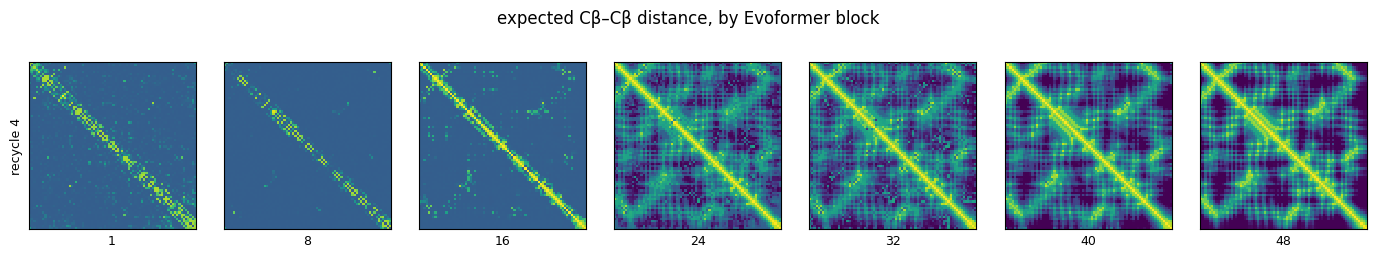

In [59]:
bins = torch.linspace(2.3125, 21.6875, 63, device=Z.device)   # AF2 bin centers
edges = torch.cat([bins, bins[-1:] + 0.3125])                  # 64th = catch-all

def expected_dist(z):
    with torch.no_grad():
        p = model.aux_heads.distogram(z).softmax(-1)
        p = (p + p.transpose(0, 1)) / 2        # head output is symmetrized
    return (p * edges).sum(-1)

blocks = [0, 7, 15, 23, 31, 39, 47]
maps = [expected_dist(Z[-1, b]).cpu().numpy() for b in blocks]

fig, axes = plt.subplots(1, len(blocks), figsize=(2.0*len(blocks), 2.3))
vmin, vmax = 3, 22
for ax, b, m in zip(axes, blocks, maps):
    ax.imshow(m, cmap="viridis_r", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f"{b+1}", fontsize=9)
axes[0].set_ylabel("recycle 4", fontsize=9)
fig.suptitle("expected C\u03b2\u2013C\u03b2 distance, by Evoformer block", y=1.02)
plt.tight_layout(); plt.show()

In [60]:
def diag(z):
    with torch.no_grad():
        p = model.aux_heads.distogram(z).softmax(-1)
    ent = -(p * (p + 1e-9).log()).sum(-1).mean()
    return ent.item(), z.norm(dim=-1).std().item()

for b in range(0, 48, 4):
    e, n = diag(Z[-1, b])
    print(f"block {b+1:2d}  entropy {e:.3f}  pair-norm std {n:.3f}")

block  1  entropy 0.598  pair-norm std 58.559
block  5  entropy 0.573  pair-norm std 91.741
block  9  entropy 0.593  pair-norm std 143.866
block 13  entropy 0.596  pair-norm std 195.760
block 17  entropy 0.572  pair-norm std 235.515
block 21  entropy 1.282  pair-norm std 270.957
block 25  entropy 1.560  pair-norm std 327.152
block 29  entropy 1.523  pair-norm std 344.769
block 33  entropy 1.447  pair-norm std 340.414
block 37  entropy 1.355  pair-norm std 328.905
block 41  entropy 1.385  pair-norm std 307.472
block 45  entropy 1.285  pair-norm std 284.946


In [61]:
for b in [0, 8, 16, 20, 24, 47]:
    z = Z[-1, b]
    with torch.no_grad():
        lg = model.aux_heads.distogram(z)
        p = lg.softmax(-1)
    ed = (p * edges).sum(-1)
    print(f"block {b+1:2d}  |z| {z.norm(dim=-1).mean():.1f}  "
          f"logit range {lg.min():.1f}..{lg.max():.1f}  "
          f"E[d] {ed.mean():.1f} A  argmax-bin mode {p.argmax(-1).float().mean():.1f}")

block  1  |z| 359.2  logit range -95.3..78.5  E[d] 15.6 A  argmax-bin mode 43.0
block  9  |z| 367.7  logit range -161.0..106.0  E[d] 16.0 A  argmax-bin mode 43.9
block 17  |z| 378.0  logit range -163.2..105.7  E[d] 15.2 A  argmax-bin mode 41.4
block 21  |z| 348.9  logit range -155.3..100.9  E[d] 14.4 A  argmax-bin mode 38.8
block 25  |z| 375.1  logit range -190.7..96.8  E[d] 14.7 A  argmax-bin mode 40.1
block 48  |z| 234.4  logit range -179.8..182.9  E[d] 15.0 A  argmax-bin mode 40.6


In [62]:
lr = np.abs(np.arange(76)[:,None] - np.arange(76)[None,:]) > 12
for b in range(0, 48, 4):
    with torch.no_grad():
        p = model.aux_heads.distogram(Z[-1, b]).softmax(-1)
    ed = (((p + p.transpose(0,1))/2) * edges).sum(-1).cpu().numpy()
    cm = (ed < 8).astype(float)
    tp = ((cm==1)&(ref_cm==1)&lr).sum()
    fp = ((cm==1)&(ref_cm==0)&lr).sum()
    fn = ((cm==0)&(ref_cm==1)&lr).sum()
    print(f"block {b+1:2d}  n_pred {int(tp+fp):4d}  precision {tp/max(tp+fp,1):.3f}  recall {tp/max(tp+fn,1):.3f}")

block  1  n_pred    6  precision 1.000  recall 0.033
block  5  n_pred    2  precision 1.000  recall 0.011
block  9  n_pred    4  precision 1.000  recall 0.022
block 13  n_pred   18  precision 0.889  recall 0.089
block 17  n_pred   18  precision 0.889  recall 0.089
block 21  n_pred   44  precision 0.773  recall 0.189
block 25  n_pred   28  precision 0.857  recall 0.133
block 29  n_pred   62  precision 0.935  recall 0.322
block 33  n_pred   68  precision 0.941  recall 0.356
block 37  n_pred  116  precision 0.845  recall 0.544
block 41  n_pred  156  precision 0.859  recall 0.744
block 45  n_pred  182  precision 0.802  recall 0.811


In [63]:
with torch.no_grad():
    p = model.aux_heads.distogram(Z[-1, 0]).softmax(-1)
ed = (((p + p.transpose(0,1))/2) * edges).sum(-1).cpu().numpy()
ii, jj = np.where((ed < 8) & lr)
for a, b in zip(ii, jj):
    if a < b:
        print(f"({a+1:2d}, {b+1:2d})  sep {b-a:2d}  true dist {ref_d[a,b]:.1f} A")

( 3, 17)  sep 14  true dist 7.2 A
(19, 57)  sep 38  true dist 4.7 A
(44, 70)  sep 26  true dist 7.8 A


In [64]:
with torch.no_grad():
    p = model.aux_heads.distogram(Z[0, 0]).softmax(-1)
ed = (((p + p.transpose(0,1))/2) * edges).sum(-1).cpu().numpy()
ii, jj = np.where((ed < 8) & lr)
for a, b in zip(ii, jj):
    if a < b:
        print(f"({a+1:2d}, {b+1:2d})  sep {b-a:2d}  true dist {ref_d[a,b]:.1f} A")

(19, 57)  sep 38  true dist 4.7 A
(24, 53)  sep 29  true dist 6.5 A
(44, 70)  sep 26  true dist 7.8 A


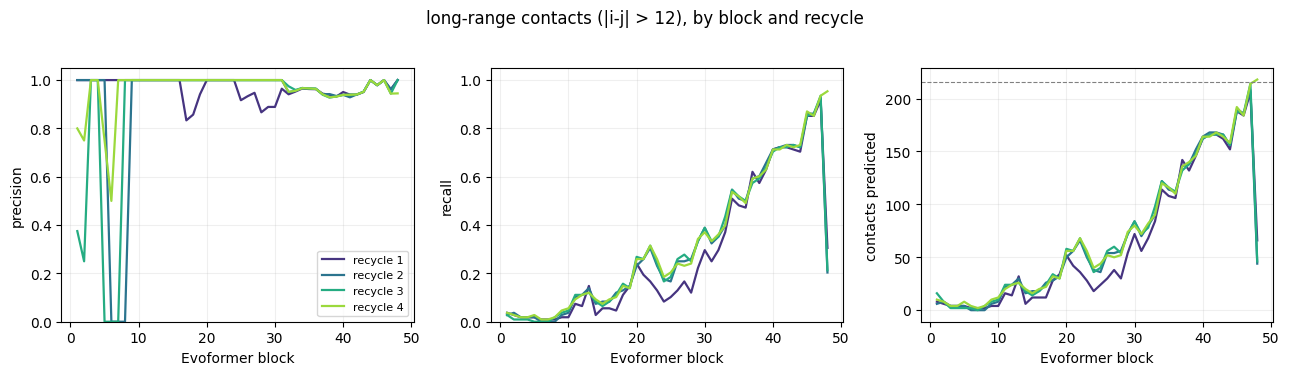

final: precision 0.945  recall 0.954  n 218
block 1, recycle 1: precision 1.000  recall 0.037  n 8


In [70]:
lr = np.abs(np.arange(76)[:, None] - np.arange(76)[None, :]) > 12
n_rec, n_blk = Z.shape[0], Z.shape[1]

CONTACT_BIN = int((8.0 - 2.3125) / 0.3125) + 1   # verify against your bin centers
def contact_prob(z, thresh=0.5):
    with torch.no_grad():
        p = model.aux_heads.distogram(z).softmax(-1)
        p = (p + p.transpose(0, 1)) / 2
        pc = p[..., :CONTACT_BIN].sum(-1)
    return (pc > thresh).cpu().numpy().astype(float), pc.cpu().numpy()

prec = np.zeros((n_rec, n_blk))
rec  = np.zeros((n_rec, n_blk))
npred = np.zeros((n_rec, n_blk), dtype=int)

for r in range(n_rec):
    for b in range(n_blk):
        cm, _ = contact_prob(Z[r, b])
        tp = ((cm == 1) & (ref_cm == 1) & lr).sum()
        fp = ((cm == 1) & (ref_cm == 0) & lr).sum()
        fn = ((cm == 0) & (ref_cm == 1) & lr).sum()
        prec[r, b]  = tp / max(tp + fp, 1)
        rec[r, b]   = tp / max(tp + fn, 1)
        npred[r, b] = tp + fp

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_rec))
x = np.arange(1, n_blk + 1)

for r in range(n_rec):
    axes[0].plot(x, prec[r], color=colors[r], lw=1.6, label=f"recycle {r+1}")
    axes[1].plot(x, rec[r],  color=colors[r], lw=1.6)
    axes[2].plot(x, npred[r], color=colors[r], lw=1.6)

axes[0].set_ylabel("precision"); axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8)
axes[1].set_ylabel("recall");    axes[1].set_ylim(0, 1.05)
axes[2].set_ylabel("contacts predicted")
axes[2].axhline((ref_cm * lr).sum(), ls="--", lw=0.8, c="gray")
for ax in axes:
    ax.set_xlabel("Evoformer block"); ax.grid(alpha=0.2)
fig.suptitle("long-range contacts (|i-j| > 12), by block and recycle", y=1.03)
plt.tight_layout(); plt.show()

print("final:", f"precision {prec[-1,-1]:.3f}  recall {rec[-1,-1]:.3f}  n {npred[-1,-1]}")
print("block 1, recycle 1:", f"precision {prec[0,0]:.3f}  recall {rec[0,0]:.3f}  n {npred[0,0]}")

210 / 216 true long-range contacts ever predicted (97%)


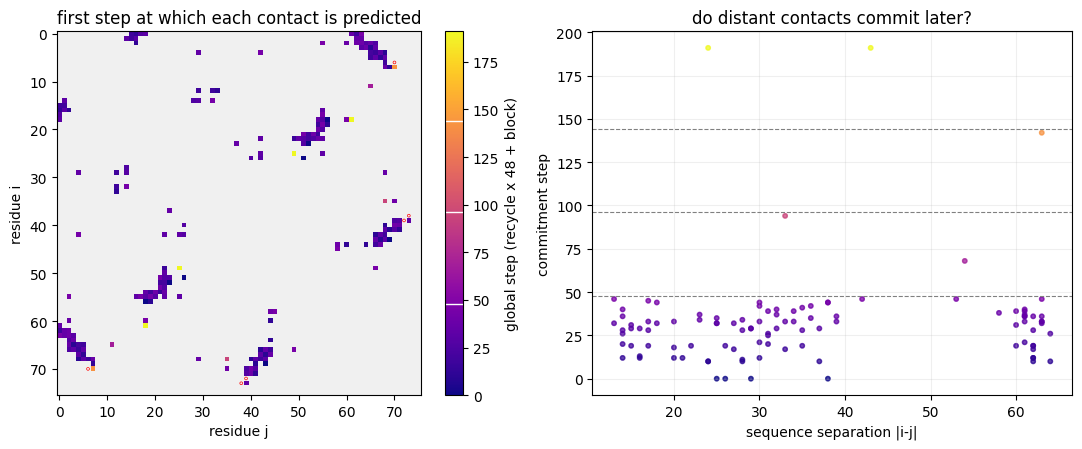


earliest commitments:
  (27, 52)  sep 25  step   0 (recycle 1, block 1)  true 7.1 A
  (19, 57)  sep 38  step   0 (recycle 1, block 1)  true 4.0 A
  (44, 70)  sep 26  step   0 (recycle 1, block 1)  true 6.5 A
  (24, 53)  sep 29  step   0 (recycle 1, block 1)  true 5.8 A
  (20, 57)  sep 37  step  10 (recycle 1, block 11)  true 6.4 A
  ( 5, 69)  sep 64  step  10 (recycle 1, block 11)  true 5.1 A
  (44, 68)  sep 24  step  10 (recycle 1, block 11)  true 4.1 A
  ( 4, 66)  sep 62  step  10 (recycle 1, block 11)  true 4.3 A
  (43, 67)  sep 24  step  10 (recycle 1, block 11)  true 5.1 A
  (42, 70)  sep 28  step  10 (recycle 1, block 11)  true 4.5 A


In [74]:
# first (recycle, block) at which each true long-range contact is predicted,
# flattened to a global step index 0..191
commit = np.full((76, 76), np.nan)

for r in range(n_rec):
    for b in range(n_blk):
        cm, _ = contact_prob(Z[r, b])
        step = r * n_blk + b
        newly = (cm == 1) & (ref_cm == 1) & lr & np.isnan(commit)
        commit[newly] = step

true_lr = (ref_cm == 1) & lr
n_true = true_lr.sum()
n_found = np.sum(~np.isnan(commit))
print(f"{n_found} / {n_true} true long-range contacts ever predicted "
      f"({100*n_found/n_true:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# left: commitment map
masked = np.ma.masked_invalid(commit)
cmap = plt.cm.plasma.copy(); cmap.set_bad("#f0f0f0")
im = axes[0].imshow(masked, cmap=cmap, vmin=0, vmax=n_rec*n_blk-1,
                    interpolation="nearest", origin="upper")
# never-predicted true contacts in outline
ni, nj = np.where(true_lr & np.isnan(commit))
axes[0].scatter(nj, ni, s=4, facecolors="none", edgecolors="red", lw=0.5)
axes[0].set_xlabel("residue j"); axes[0].set_ylabel("residue i")
axes[0].set_title("first step at which each contact is predicted")
cb = fig.colorbar(im, ax=axes[0], fraction=0.046)
cb.set_label("global step (recycle x 48 + block)")
for r in range(1, n_rec):
    cb.ax.axhline(r*n_blk, c="white", lw=1)

# right: commitment step vs sequence separation
ci, cj = np.where(~np.isnan(commit))
sep = np.abs(ci - cj)
axes[1].scatter(sep, commit[ci, cj], s=10, alpha=0.5, c=commit[ci, cj], cmap="plasma")
for r in range(1, n_rec):
    axes[1].axhline(r*n_blk, ls="--", lw=0.8, c="gray")
axes[1].set_xlabel("sequence separation |i-j|")
axes[1].set_ylabel("commitment step")
axes[1].set_title("do distant contacts commit later?")
axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()

# earliest ten commitments
order = np.argsort(commit[ci, cj])[:20]
print("\nearliest commitments:")
seen = set()
for k in order:
    a, b_ = ci[k], cj[k]
    if a > b_ or (a, b_) in seen: continue
    seen.add((a, b_))
    s = int(commit[a, b_])
    print(f"  ({a+1:2d}, {b_+1:2d})  sep {abs(b_-a):2d}  step {s:3d} "
          f"(recycle {s//n_blk+1}, block {s%n_blk+1})  true {ref_d[a,b_]:.1f} A")

In [72]:
# extract CB from 1UBQ (CA for glycine) and rebuild the reference
def cb_coords_from_pdb(path, chain=None):
    res = {}
    for line in pathlib.Path(path).read_text().splitlines():
        if not line.startswith("ATOM"): continue
        if line[16] not in (" ", "A"): continue
        if chain is not None and line[21] != chain: continue
        name, num = line[12:16].strip(), int(line[22:26])
        if name in ("CB", "CA"):
            xyz = [float(line[30:38]), float(line[38:46]), float(line[46:54])]
            res.setdefault(num, {})[name] = xyz
    nums = sorted(res)
    coords = [res[n].get("CB", res[n]["CA"]) for n in nums]
    return np.array(nums), np.array(coords)

ref_nums, ref_cb = cb_coords_from_pdb(ref_path, chain="A")
ref_cm, ref_d = contact_map_from_ca(ref_cb)

print("CA contacts:", int((ref_cm * lr).sum()), " CB contacts:", int((ref_cm_cb * lr).sum()))

CA contacts: 216  CB contacts: 216


In [73]:
ref_nums, ref_cb = cb_coords_from_pdb(ref_path, chain="A")
ref_cm, ref_d = contact_map_from_ca(ref_cb)

# re-derive the index mapping — ref_nums changed
common = np.intersect1d(ref_nums, pred_nums)
ri = np.searchsorted(ref_nums, common)
pi = np.searchsorted(pred_nums, common)
assert len(common) == len(SEQUENCE), len(common)

print("true long-range contacts:", int((ref_cm * lr).sum()))

true long-range contacts: 216


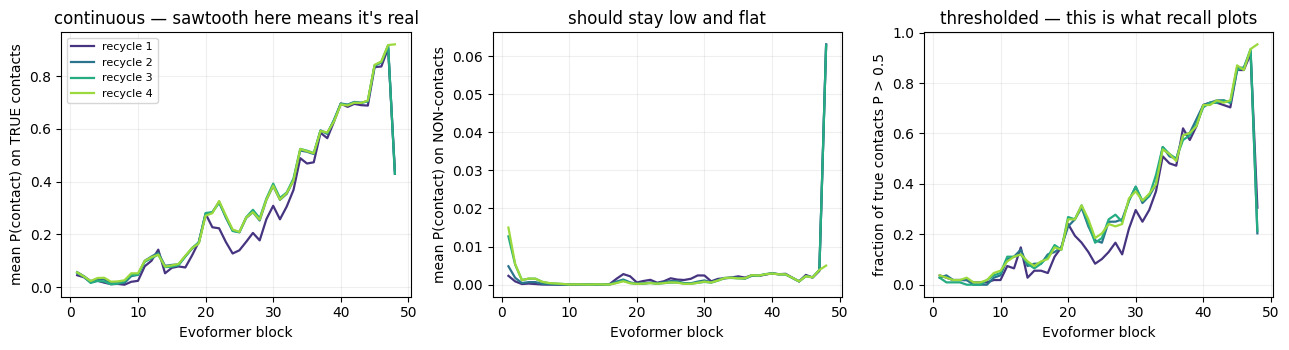

residual std, continuous P(contact): 0.0380
residual std, thresholded fraction : 0.0389
ratio (thresh/cont): 1.0x


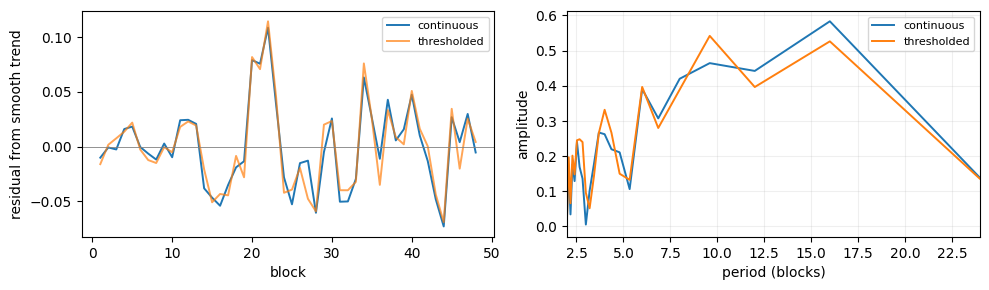

In [75]:
true_lr = (ref_cm == 1) & lr
false_lr = (ref_cm == 0) & lr

pc_true  = np.zeros((n_rec, n_blk))
pc_false = np.zeros((n_rec, n_blk))
pc_frac  = np.zeros((n_rec, n_blk))   # fraction of true contacts over threshold

for r in range(n_rec):
    for b in range(n_blk):
        _, pc = contact_prob(Z[r, b])
        pc_true[r, b]  = pc[true_lr].mean()
        pc_false[r, b] = pc[false_lr].mean()
        pc_frac[r, b]  = (pc[true_lr] > 0.5).mean()

x = np.arange(1, n_blk + 1)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_rec))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)

for r in range(n_rec):
    axes[0].plot(x, pc_true[r],  color=colors[r], lw=1.6, label=f"recycle {r+1}")
    axes[1].plot(x, pc_false[r], color=colors[r], lw=1.6)
    axes[2].plot(x, pc_frac[r],  color=colors[r], lw=1.6)

axes[0].set_ylabel("mean P(contact) on TRUE contacts")
axes[0].set_title("continuous — sawtooth here means it's real")
axes[0].legend(fontsize=8)
axes[1].set_ylabel("mean P(contact) on NON-contacts")
axes[1].set_title("should stay low and flat")
axes[2].set_ylabel("fraction of true contacts P > 0.5")
axes[2].set_title("thresholded — this is what recall plots")
for ax in axes:
    ax.set_xlabel("Evoformer block"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# quantify the oscillation: residual after a smooth trend
from numpy.polynomial import polynomial as P
def wiggle(series, deg=6):
    c = P.polyfit(x, series, deg)
    resid = series - P.polyval(x, c)
    return resid, resid.std()

r_cont, s_cont = wiggle(pc_true[-1])
r_thr,  s_thr  = wiggle(pc_frac[-1])
print(f"residual std, continuous P(contact): {s_cont:.4f}")
print(f"residual std, thresholded fraction : {s_thr:.4f}")
print(f"ratio (thresh/cont): {s_thr/max(s_cont,1e-9):.1f}x")

# periodicity of the residual
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(x, r_cont, lw=1.4, label="continuous")
ax[0].plot(x, r_thr,  lw=1.4, label="thresholded", alpha=0.7)
ax[0].axhline(0, c="gray", lw=0.6); ax[0].legend(fontsize=8)
ax[0].set_xlabel("block"); ax[0].set_ylabel("residual from smooth trend")

for series, lab in [(r_cont, "continuous"), (r_thr, "thresholded")]:
    f = np.fft.rfftfreq(len(series), d=1.0)
    amp = np.abs(np.fft.rfft(series - series.mean()))
    ax[1].plot(1/np.maximum(f, 1e-9), amp, lw=1.4, label=lab)
ax[1].set_xlim(2, 24); ax[1].set_xlabel("period (blocks)"); ax[1].set_ylabel("amplitude")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()